All libraries imported successfully!
Current directory: C:\Users\User\Documents\SLIIT\Year 4 Semester 2\IT4060 - Machine Learning\Assignment
CSV files found: ['StudentPerformanceFactors.csv']

Loaded: StudentPerformanceFactors.csv

DATASET LOADED SUCCESSFULLY
Shape: (6607, 20)
Rows: 6607
Columns: 20

Column names: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

FIRST 5 ROWS

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   in

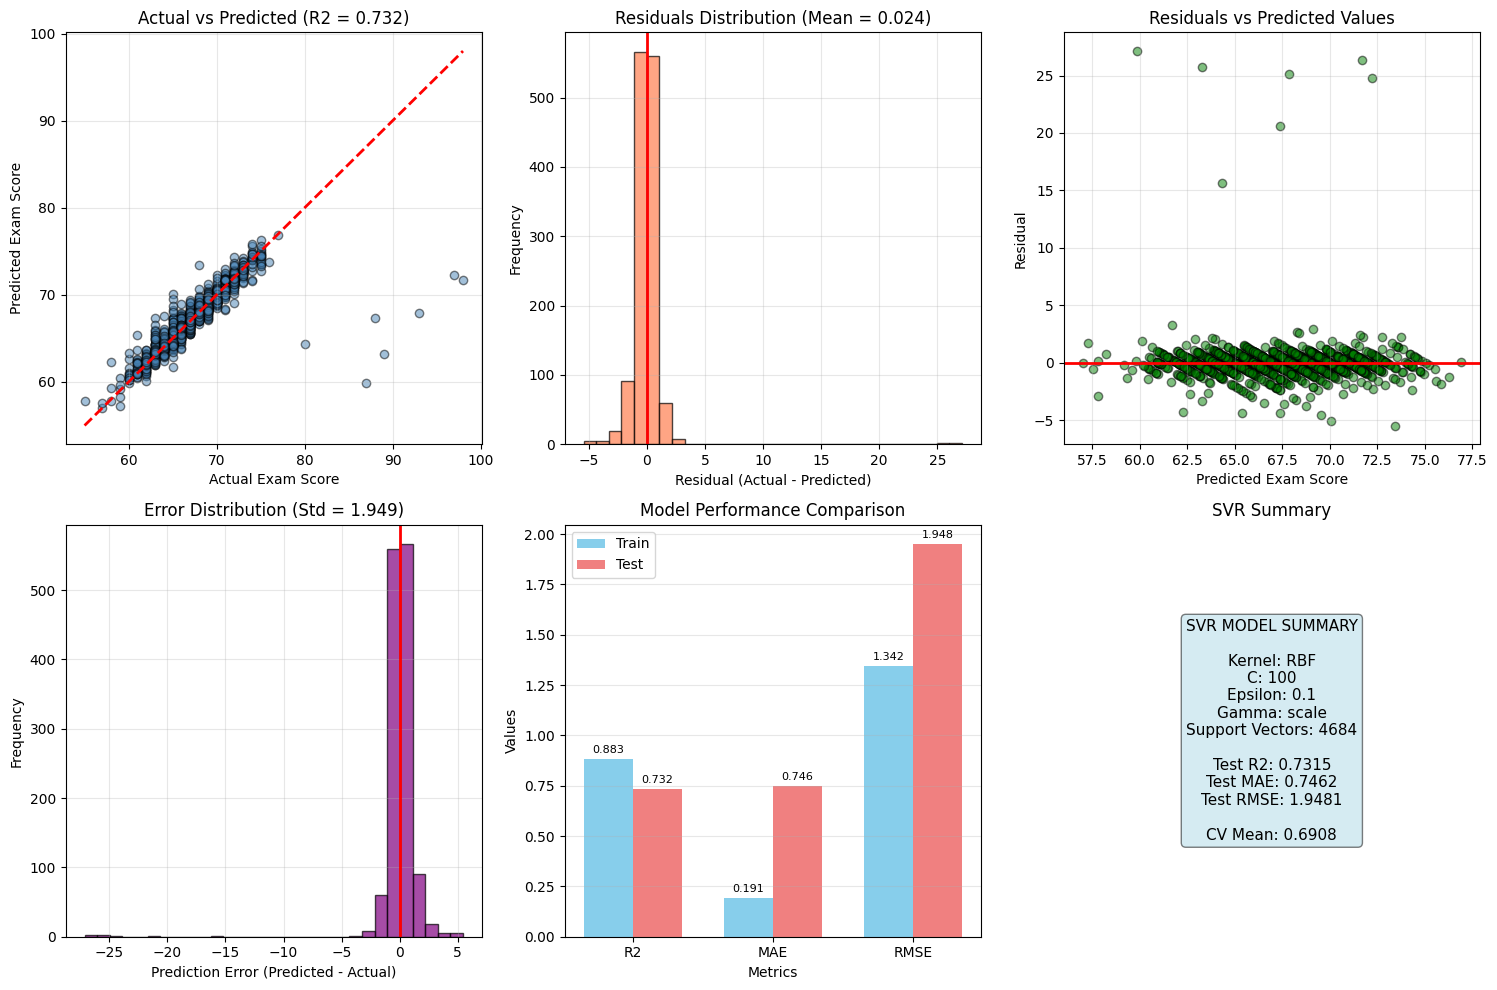


Visualizations saved as 'svr_visualizations.png'
Model saved to 'models/svr_model.pkl'
Scaler saved to 'models/scaler.pkl'
Label encoders saved to 'models/label_encoders.pkl'
Metrics saved to 'models/svr_metrics.pkl'

PREDICTION FUNCTION READY

SVR MODEL TRAINING COMPLETED

Dataset Summary:
   Total samples: 6607
   Features: 19
   Target: Exam_Score

Model Configuration:
   Algorithm: SVR with RBF kernel
   C: 100
   Epsilon: 0.1
   Gamma: scale

Final Test Performance:
   R2 Score: 0.7315
   MAE: 0.7462
   RMSE: 1.9481
   MAPE: 1.07%

SUCCESS


In [2]:
# %% [markdown]
# # SVR Model for Student Exam Score Prediction
# 
# ## Support Vector Regression with RBF Kernel

# %% [markdown]
# ## 1. Import Required Libraries

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import warnings
import os
import joblib

warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

# %% [markdown]
# ## 2. Load Dataset (Local File)

# %%
# Check current directory
print(f"Current directory: {os.getcwd()}")

# List CSV files in current directory
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
print(f"CSV files found: {csv_files}")

# Load the dataset
if len(csv_files) > 0:
    filename = csv_files[0]
    df = pd.read_csv(filename)
    print(f"\nLoaded: {filename}")
else:
    filename = input("Enter the path to your CSV file: ")
    df = pd.read_csv(filename)

print("\n" + "=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:", df.columns.tolist())

# %% [markdown]
# ## 3. Initial Data Exploration

# %%
# Display first few rows
print("\n" + "=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
df.head()

# %%
# Dataset information
print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
df.info()

# %%
# Statistical summary
print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
df.describe()

# %%
# Check missing values
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing_values = df.isnull().sum()
missing_df = missing_values[missing_values > 0]
if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values found")

# %% [markdown]
# ## 4. Data Preprocessing

# %%
# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

print("\n" + "=" * 60)
print("CATEGORICAL COLUMNS")
print("=" * 60)
if len(categorical_columns) > 0:
    for col in categorical_columns:
        print(f"  - {col} ({df[col].nunique()} unique values)")
else:
    print("No categorical columns found")

# Handle missing values
print("\n" + "=" * 60)
print("HANDLING MISSING VALUES")
print("=" * 60)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if col in categorical_columns:
            mode_val = df[col].mode()[0]
            missing_count = df[col].isnull().sum()
            df[col].fillna(mode_val, inplace=True)
            print(f"  - {col}: Filled {missing_count} missing values with mode")
        else:
            median_val = df[col].median()
            missing_count = df[col].isnull().sum()
            df[col].fillna(median_val, inplace=True)
            print(f"  - {col}: Filled {missing_count} missing values with median")

print(f"\nTotal missing values after processing: {df.isnull().sum().sum()}")

# Encode categorical variables
print("\n" + "=" * 60)
print("ENCODING CATEGORICAL VARIABLES")
print("=" * 60)
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"  - {col}: Encoded {len(le.classes_)} values")

# Separate features and target
target_column = 'Exam_Score'
if target_column not in df.columns:
    print(f"\nWarning: '{target_column}' not found!")
    print(f"Available columns: {df.columns.tolist()}")
    target_column = input("Enter target column name: ")

feature_columns = [col for col in df.columns if col != target_column]
X = df[feature_columns]
y = df[target_column]

print("\n" + "=" * 60)
print("FEATURES AND TARGET")
print("=" * 60)
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target range: {y.min():.1f} - {y.max():.1f}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n" + "=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)
print(f"Training: {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Testing: {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.0f}%)")

# Feature scaling for SVR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep as numpy arrays (no conversion to DataFrame needed)
print("\n" + "=" * 60)
print("FEATURE SCALING")
print("=" * 60)
print("Features scaled using StandardScaler")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

# %% [markdown]
# ## 5. Train SVR Model

# %%
# Train SVR with parameters (C=100, epsilon=0.1, gamma='scale')
print("\n" + "=" * 60)
print("TRAINING SVR MODEL")
print("=" * 60)
print("Parameters:")
print("   Kernel: rbf")
print("   C: 100")
print("   Gamma: scale")
print("   Epsilon: 0.1")

# Create and train SVR model
svr_model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)

print("\n" + "=" * 60)
print("MODEL INFORMATION")
print("=" * 60)
print(f"Kernel: {svr_model.kernel}")
print(f"C: {svr_model.C}")
print(f"Epsilon: {svr_model.epsilon}")
print(f"Gamma: {svr_model.gamma}")
print(f"Support vectors: {sum(svr_model.n_support_)}")

# %% [markdown]
# ## 6. Model Evaluation

# %%
# Make predictions
y_train_pred = svr_model.predict(X_train_scaled)
y_test_pred = svr_model.predict(X_test_scaled)

# Calculate metrics
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mape = mean_absolute_percentage_error(y_train, y_train_pred) * 100

test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print("\nTraining Set:")
print(f"   R2 Score: {train_r2:.4f}")
print(f"   MAE: {train_mae:.4f}")
print(f"   RMSE: {train_rmse:.4f}")
print(f"   MAPE: {train_mape:.2f}%")

print("\nTest Set:")
print(f"   R2 Score: {test_r2:.4f}")
print(f"   MAE: {test_mae:.4f}")
print(f"   RMSE: {test_rmse:.4f}")
print(f"   MAPE: {test_mape:.2f}%")

# Cross-validation - FIXED: Use numpy arrays directly
# Combine train and test data for cross-validation
import numpy as np
X_all = np.vstack([X_train_scaled, X_test_scaled])
y_all = np.concatenate([y_train.values if hasattr(y_train, 'values') else y_train, 
                         y_test.values if hasattr(y_test, 'values') else y_test])

cv_scores = cross_val_score(svr_model, X_all, y_all, cv=5, scoring='r2')

print("\n" + "=" * 60)
print("5-FOLD CROSS-VALIDATION")
print("=" * 60)
print(f"CV Scores: {[round(x, 4) for x in cv_scores]}")
print(f"Mean CV R2: {cv_scores.mean():.4f}")
print(f"Std CV R2: {cv_scores.std():.4f}")

# Overfitting check
r2_gap = train_r2 - test_r2
print("\nOverfitting Analysis:")
print(f"   R2 gap: {r2_gap:.4f}")
if r2_gap > 0.1:
    print("   Mild overfitting detected")
else:
    print("   No significant overfitting")

# %% [markdown]
# ## 7. Visualizations

# %%
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.5, edgecolors='k', color='steelblue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Exam Score')
axes[0, 0].set_ylabel('Predicted Exam Score')
axes[0, 0].set_title(f'Actual vs Predicted (R2 = {test_r2:.3f})')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals Distribution
residuals = y_test - y_test_pred
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].axvline(0, color='red', linestyle='-', lw=2)
axes[0, 1].set_xlabel('Residual (Actual - Predicted)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Residuals Distribution (Mean = {residuals.mean():.3f})')
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals vs Predicted
axes[0, 2].scatter(y_test_pred, residuals, alpha=0.5, edgecolors='k', color='green')
axes[0, 2].axhline(0, color='red', linestyle='-', lw=2)
axes[0, 2].set_xlabel('Predicted Exam Score')
axes[0, 2].set_ylabel('Residual')
axes[0, 2].set_title('Residuals vs Predicted Values')
axes[0, 2].grid(True, alpha=0.3)

# 4. Error Distribution
errors = y_test_pred - y_test
axes[1, 0].hist(errors, bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1, 0].axvline(0, color='red', linestyle='-', lw=2)
axes[1, 0].set_xlabel('Prediction Error (Predicted - Actual)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title(f'Error Distribution (Std = {errors.std():.3f})')
axes[1, 0].grid(True, alpha=0.3)

# 5. Metrics Comparison
metrics_names = ['R2', 'MAE', 'RMSE']
train_metrics = [train_r2, train_mae, train_rmse]
test_metrics = [test_r2, test_mae, test_rmse]

x = np.arange(len(metrics_names))
width = 0.35
bars1 = axes[1, 1].bar(x - width/2, train_metrics, width, label='Train', color='skyblue')
bars2 = axes[1, 1].bar(x + width/2, test_metrics, width, label='Test', color='lightcoral')
axes[1, 1].set_xlabel('Metrics')
axes[1, 1].set_ylabel('Values')
axes[1, 1].set_title('Model Performance Comparison')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics_names)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    axes[1, 1].annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    axes[1, 1].annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

# 6. Model Summary
axes[1, 2].axis('off')
summary_text = f'SVR MODEL SUMMARY\n\n' \
               f'Kernel: RBF\n' \
               f'C: 100\n' \
               f'Epsilon: 0.1\n' \
               f'Gamma: scale\n' \
               f'Support Vectors: {sum(svr_model.n_support_)}\n\n' \
               f'Test R2: {test_r2:.4f}\n' \
               f'Test MAE: {test_mae:.4f}\n' \
               f'Test RMSE: {test_rmse:.4f}\n\n' \
               f'CV Mean: {cv_scores.mean():.4f}'

axes[1, 2].text(0.5, 0.5, summary_text, ha='center', va='center', fontsize=11,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
axes[1, 2].set_title('SVR Summary', fontsize=12)

plt.tight_layout()
plt.savefig('svr_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nVisualizations saved as 'svr_visualizations.png'")

# %% [markdown]
# ## 8. Save Model

# %%
# Create models directory
os.makedirs('models', exist_ok=True)

# Save the trained model
joblib.dump(svr_model, 'models/svr_model.pkl')
print("Model saved to 'models/svr_model.pkl'")

# Save the scaler
joblib.dump(scaler, 'models/scaler.pkl')
print("Scaler saved to 'models/scaler.pkl'")

# Save the label encoders
joblib.dump(label_encoders, 'models/label_encoders.pkl')
print("Label encoders saved to 'models/label_encoders.pkl'")

# Save metrics
metrics = {
    'train': {'R2': train_r2, 'MAE': train_mae, 'RMSE': train_rmse, 'MAPE': train_mape},
    'test': {'R2': test_r2, 'MAE': test_mae, 'RMSE': test_rmse, 'MAPE': test_mape},
    'cv_mean': cv_scores.mean(),
    'cv_std': cv_scores.std(),
    'cv_scores': cv_scores.tolist(),
    'best_params': {'C': 100, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'},
    'feature_columns': feature_columns
}
joblib.dump(metrics, 'models/svr_metrics.pkl')
print("Metrics saved to 'models/svr_metrics.pkl'")

# %% [markdown]
# ## 9. Prediction Function

# %%
def predict_exam_score(new_data):
    """
    Predict exam score for new student
    
    Parameters:
    new_data: Dictionary with feature values
    
    Returns:
    Predicted exam score
    """
    # Convert to DataFrame
    if isinstance(new_data, dict):
        new_data = pd.DataFrame([new_data])
    
    # Encode categorical features
    for col in label_encoders.keys():
        if col in new_data.columns:
            le = label_encoders[col]
            new_data[col] = new_data[col].apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )
    
    # Reorder columns
    new_data = new_data[feature_columns]
    
    # Scale features
    new_data_scaled = scaler.transform(new_data)
    
    # Predict
    prediction = svr_model.predict(new_data_scaled)
    
    return prediction[0]

print("\n" + "=" * 60)
print("PREDICTION FUNCTION READY")
print("=" * 60)

# %% [markdown]
# ## 10. Final Summary

# %%
print("\n" + "=" * 60)
print("SVR MODEL TRAINING COMPLETED")
print("=" * 60)

print("\nDataset Summary:")
print(f"   Total samples: {len(df)}")
print(f"   Features: {len(feature_columns)}")
print(f"   Target: {target_column}")

print("\nModel Configuration:")
print("   Algorithm: SVR with RBF kernel")
print("   C: 100")
print("   Epsilon: 0.1")
print("   Gamma: scale")

print("\nFinal Test Performance:")
print(f"   R2 Score: {test_r2:.4f}")
print(f"   MAE: {test_mae:.4f}")
print(f"   RMSE: {test_rmse:.4f}")
print(f"   MAPE: {test_mape:.2f}%")

print("\n" + "=" * 60)
print("SUCCESS")
print("=" * 60)